# Principle Component Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv('D:/Broadway/Data Science - 2/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
encoder = LabelEncoder()

In [4]:
df['GenderID'] = encoder.fit_transform(df['Gender'])
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),GenderID
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,1


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'GenderID'],
      dtype='object')

In [6]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'GenderID']

In [7]:
X = df[features]

In [8]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

In [9]:
# X_scale

In [10]:
# n_components -> number of components
model = PCA(n_components = len(features))

In [11]:
X_model = model.fit_transform(X_scale)

In [12]:
# configure principle components
loadings = pd.DataFrame(
    model.components_, # value get from X_model = model.fit_transform(X_scale)
    index=features,
    columns=[f'PC{i+1}' for i in range(len(features))]
)

In [13]:
loadings

,PC1,PC2,PC3,PC4
Age,0.687900,-0.006082,-0.686920,0.234302
Annual Income (k$),-0.103690,0.765252,0.103211,0.626886
Spending Score (1-100),-0.122384,-0.643667,0.136573,0.743009
GenderID,0.707859,0.006721,0.706283,-0.007405


In [15]:
# PC1 and PC2
# X - pc1 -> Age, Spending Score (1-100), GenderID
# Y - pc2 -> Annual Income (k$)

Text(0, 0.5, 'Principle Component 2')

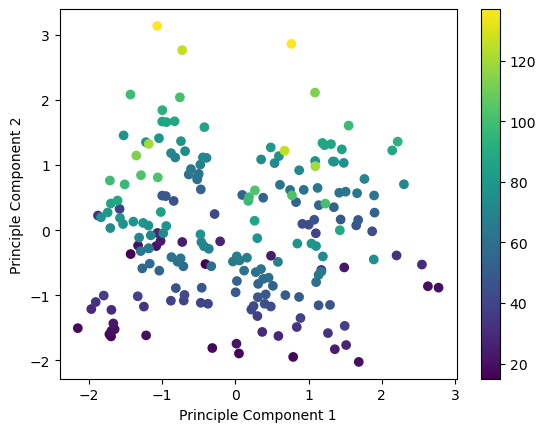

In [16]:
scatter = plt.scatter(X_model[:,0], X_model[:,1], c=df['Annual Income (k$)'])
plt.colorbar(scatter)
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')